#Завантаження данних (таблиць)

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from google.colab import files
from io import BytesIO
import base64
from datetime import datetime

In [2]:
# Helpers: capture matplotlib figure -> base64 -> HTML section
REPORT_SECTIONS = []
SHOW_INLINE = True  # якщо True — показує графіки в ноутбуці + додає в HTML

def _fig_to_base64(fig) -> str:
    """Convert matplotlib figure to base64-encoded PNG string."""
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=160, bbox_inches="tight")
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

def add_current_fig(title: str, subtitle: str = ""):
    """Capture current matplotlib figure (gcf), add to report as embedded image."""
    fig = plt.gcf()
    img_b64 = _fig_to_base64(fig)

    section_html = f"""
    <section class="card">
      <h2>{title}</h2>
      {f"<p class='subtitle'>{subtitle}</p>" if subtitle else ""}
      <img class="plot" src="data:image/png;base64,{img_b64}" />
    </section>
    """
    REPORT_SECTIONS.append(section_html)

    if SHOW_INLINE:
        plt.show()
    plt.close(fig)

def save_report_html(filename="cohort_report.html"):
    """Assemble and save the HTML report (single file)."""
    created_at = datetime.now().strftime("%Y-%m-%d %H:%M")
    html = f"""
    <!doctype html>
    <html lang="uk">
    <head>
      <meta charset="utf-8"/>
      <meta name="viewport" content="width=device-width, initial-scale=1"/>
      <title>Cohort Analysis Report</title>
      <style>
        body {{ font-family: Arial, sans-serif; margin: 0; background: #f6f7fb; color:#111; }}
        .container {{ max-width: 1100px; margin: 0 auto; padding: 24px; }}
        .header {{ background: white; border-radius: 14px; padding: 18px 20px; margin-bottom: 18px; box-shadow: 0 6px 18px rgba(0,0,0,.06); }}
        .header h1 {{ margin: 0; font-size: 22px; }}
        .header p {{ margin: 6px 0 0; color: #555; }}
        # .grid {{ display: grid; grid-template-columns: 1fr; gap: 14px; }}
        .grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 14px; }}
        .card {{ background: white; border-radius: 14px; padding: 16px 16px 10px; box-shadow: 0 6px 18px rgba(0,0,0,.06); }}
        .card h2 {{ margin: 0 0 8px; font-size: 18px; }}
        .subtitle {{ margin: 0 0 12px; color: #666; font-size: 13px; }}
        .plot {{ width: 100%; height: auto; border-radius: 10px; border: 1px solid #eee; }}
        .footer {{ margin-top: 16px; color:#777; font-size: 12px; text-align:center; }}
        code {{ background:#f0f2f6; padding: 2px 6px; border-radius: 6px; }}
      </style>
    </head>
    <body>
      <div class="container">
        <div class="header">
          <h1>📊 Cohort Analysis Report</h1>
          <p>Згенеровано: {created_at} • Дані: <code>orders</code> + <code>customers</code></p>
        </div>

        <div class="grid">
          {''.join(REPORT_SECTIONS)}
        </div>

        <div class="footer">
          <p>Report generated in Google Colab (matplotlib/seaborn) — single HTML file.</p>
        </div>
      </div>
    </body>
    </html>
    """
    with open(filename, "w", encoding="utf-8") as f:
        f.write(html)
    return filename

In [3]:
# Завантаження файлу
from google.colab import files
uploaded = files.upload()
file_name = next(iter(uploaded))  # ім'я файлу

Saving client_base.xlsx to client_base.xlsx


In [4]:
#Лист customers
df_customers = pd.read_excel(file_name, sheet_name='customers')
df_customers.head()

,user_id,first_name,last_name,email,gender,age,city,acquisition_channel,registration_date
0,U00001,Олесь,Гавриш,oles899@yahoo.com,Male,33,селище Донецьк,Referral,2025-09-19
1,U00002,Віталій,Давиденко,vitaliy.davydenko@ukr.net,Male,25,місто Перемишляни,Instagram,2025-10-20
2,U00003,Єлисей,Архипенко,yelysey748@outlook.com,Male,48,місто Гребінка,Google Ads,2025-10-09
3,U00004,Камілла,Гаєвська,kamilla.hayevska@outlook.com,Female,19,село Славутич,Facebook,2025-08-14
4,U00005,Оксенія,Зінченко,ozinchenko@i.ua,Female,39,селище Устилуг,Email,2025-02-19


In [5]:
#Лист orders
df_orders = pd.read_excel(file_name, sheet_name='orders')
df_orders.head()

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered
3,U00001,2025-09-19,2025-11-23,ORD-251123-00004,112.16,Google Ads,Debit Card,4,5,Delivered
4,U00002,2025-10-20,2025-10-20,ORD-251020-00005,102.52,Google Ads,Credit Card,3,5,Delivered


#Створення нових стовпців

In [6]:
#Перетворюємо дати в datetime64
df_orders["registration_date"] = pd.to_datetime(df_orders["registration_date"], errors='coerce')
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"], errors='coerce')
df_orders.dtypes

,0
user_id,object
registration_date,datetime64[ns]
order_date,datetime64[ns]
order_id,object
purchase_amount,float64
order_channel,object
payment_method,object
items_count,int64
delivery_days,int64
order_status,object


In [7]:
# Cohort month label (YYYY-MM)
df_orders["cohort_month"]=df_orders["registration_date"].dt.to_period("M").astype(str)
df_orders.head(3)

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status,cohort_month
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered,2025-09
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered,2025-09
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered,2025-09


In [8]:
#Создаем стовпець order_month (YYYY-MM)
df_orders["order_month"]=df_orders["order_date"].dt.to_period("M").astype(str)
df_orders.head(3)

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status,cohort_month,order_month
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered,2025-09,2025-09
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered,2025-09,2025-10
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered,2025-09,2025-10


In [9]:
# Різниця в місяцяч між order_date та registration_date
df_orders["month_elapsed"]=((df_orders["order_date"].dt.year - df_orders["registration_date"].dt.year) *12 +(df_orders["order_date"].dt.month - df_orders["registration_date"].dt.month))
df_orders.head(3)

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status,cohort_month,order_month,month_elapsed
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered,2025-09,2025-09,0
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered,2025-09,2025-10,1
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered,2025-09,2025-10,1


#Нові клієнти та динаміка продажів

In [10]:
acq_counts=(df_orders.groupby("cohort_month")["user_id"].nunique().reset_index(name="users"))
acq_counts["cohort_month_dt"]=pd.to_datetime(acq_counts["cohort_month"])
acq_counts=acq_counts.sort_values("cohort_month_dt")
acq_counts

,cohort_month,users,cohort_month_dt
0,2025-01,317,2025-01-01
1,2025-02,291,2025-02-01
2,2025-03,215,2025-03-01
3,2025-04,206,2025-04-01
4,2025-05,221,2025-05-01
5,2025-06,178,2025-06-01
6,2025-07,452,2025-07-01
7,2025-08,317,2025-08-01
8,2025-09,228,2025-09-01
9,2025-10,208,2025-10-01


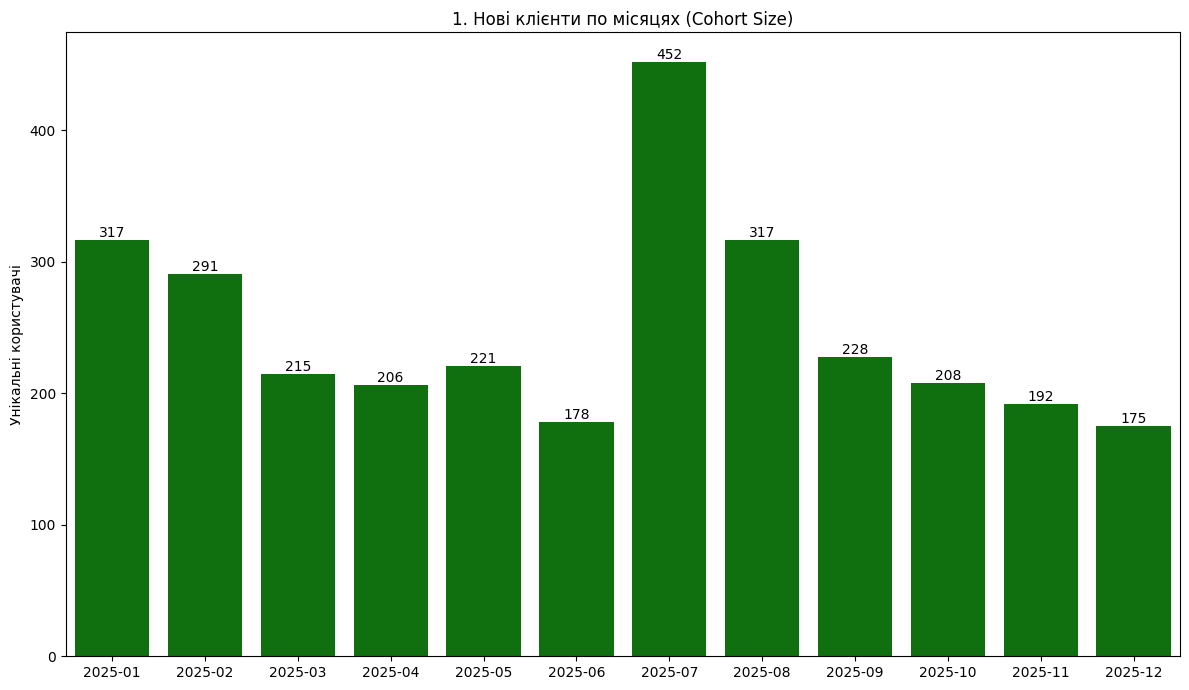

In [11]:
plt.figure(figsize=(12,7))
ax=sns.barplot(data=acq_counts, color="green", x="cohort_month", y="users")

plt.title("1. Нові клієнти по місяцях (Cohort Size)")
plt.ylabel("Унікальні користувачі")

for p in ax.patches:
    height=p.get_height()
    ax.annotate(
    f"{height:.0f}",
    (p.get_x()+p.get_width()/2, height),
    ha="center", va="bottom"
    )
plt.xlabel("")
plt.tight_layout()
add_current_fig("1) Cohort Size", "Кількість унікальних користувачів у кожній когорті (місяць реєстрації).")
plt.show()

In [12]:
#Динаміка продажів
monthly=(df_orders.groupby("order_month").agg(
    orders=("order_id", "count"), #кількість замовлень
    revenue=("purchase_amount", "sum")).reset_index()#сума доходу
)
monthly=monthly.sort_values("order_month")
monthly

,order_month,orders,revenue
0,2025-01,554,71546.12
1,2025-02,701,95787.41
2,2025-03,858,114871.56
3,2025-04,899,116906.88
4,2025-05,953,126211.02
5,2025-06,912,119791.15
6,2025-07,1299,176556.40
7,2025-08,1409,179603.16
8,2025-09,1128,150446.59
9,2025-10,1236,161706.69


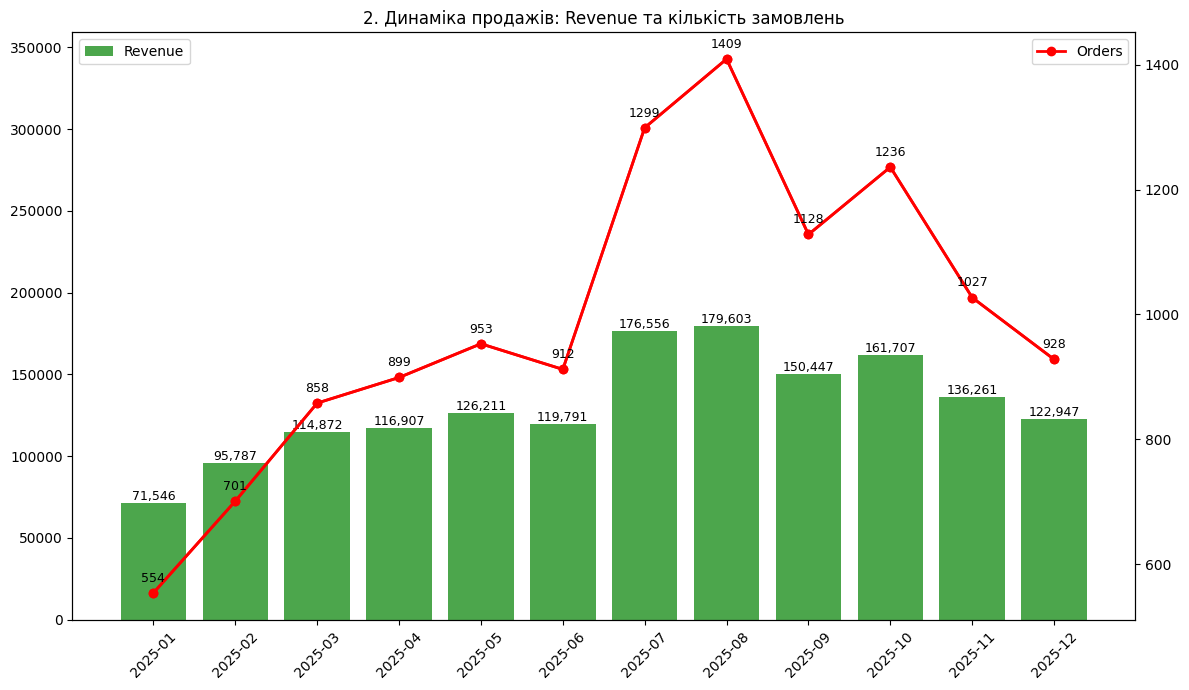

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 7))

# Стовпчики: revenue
ax1.bar(monthly["order_month"], monthly["revenue"], color="green", alpha=0.7, label="Revenue")

ax1.set_ylim(0, monthly["revenue"].max() * 2) # Розтягуємо вісь revenue вдвічі
ax1.tick_params(axis="x", rotation=45)

# Підписи на стовпчиках
for bar in ax1.patches:
   ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{bar.get_height():,.0f}", ha="center", va="bottom", fontsize=9)

ax2 = ax1.twinx() # Лінія: кількість замовлень (друга вісь)
ax2.plot(monthly["order_month"], monthly["orders"], color="red", marker="o", linewidth=2, label="Orders")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Лінія: orders
ax2.plot(monthly['order_month'], monthly['orders'], color='red', marker='o', linewidth=2, label='Orders')

# Додаємо підписи до точок
for x, y in zip(monthly['order_month'], monthly['orders']):
    ax2.annotate(
        f"{y:.0f}",              # округлення до цілого
        (x, y),                  # координати точки
        textcoords="offset points",
        xytext=(0, 8),           # зміщення тексту (0 по X, 8 пікселів по Y)
        ha="center", fontsize=9, color="black"
    )

plt.title("2. Динаміка продажів: Revenue та кількість замовлень")
plt.tight_layout()
add_current_fig("2) Revenue & Orders", "Стовпчики — revenue, лінія — кількість замовлень по місяцях.")
plt.show()

#Повернення клієнтів та Retention

In [14]:
retention_count=(
  df_orders
  .groupby(["cohort_month", "month_elapsed"])["user_id"]
  .nunique()
  .reset_index(name="users")
  )
retention_count

,cohort_month,month_elapsed,users
0,2025-01,0,317
1,2025-01,1,160
2,2025-01,2,137
3,2025-01,3,119
4,2025-01,4,75
...,...,...,...
72,2025-10,1,113
73,2025-10,2,94
74,2025-11,0,192
75,2025-11,1,95


In [15]:
#Pivot-таблиця
retention_pivot=retention_count.pivot_table(index="cohort_month", columns="month_elapsed", values="users")
retention_pivot

month_elapsed,0,1,2,3,4,5,6,7,8,9,10
cohort_month,,,,,,,,,,,
2025-01,317.0,160.0,137.0,119.0,75.0,52.0,27.0,18.0,6.0,4.0,1.0
2025-02,291.0,170.0,120.0,100.0,72.0,38.0,26.0,14.0,6.0,5.0,2.0
2025-03,215.0,112.0,96.0,66.0,40.0,24.0,18.0,9.0,5.0,3.0,NaN
2025-04,206.0,119.0,96.0,77.0,55.0,26.0,17.0,7.0,3.0,NaN,NaN
2025-05,221.0,122.0,97.0,74.0,48.0,29.0,25.0,13.0,NaN,NaN,NaN
2025-06,178.0,95.0,87.0,54.0,42.0,27.0,16.0,NaN,NaN,NaN,NaN
2025-07,452.0,248.0,178.0,174.0,113.0,59.0,NaN,NaN,NaN,NaN,NaN
2025-08,317.0,155.0,151.0,99.0,75.0,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,228.0,138.0,98.0,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


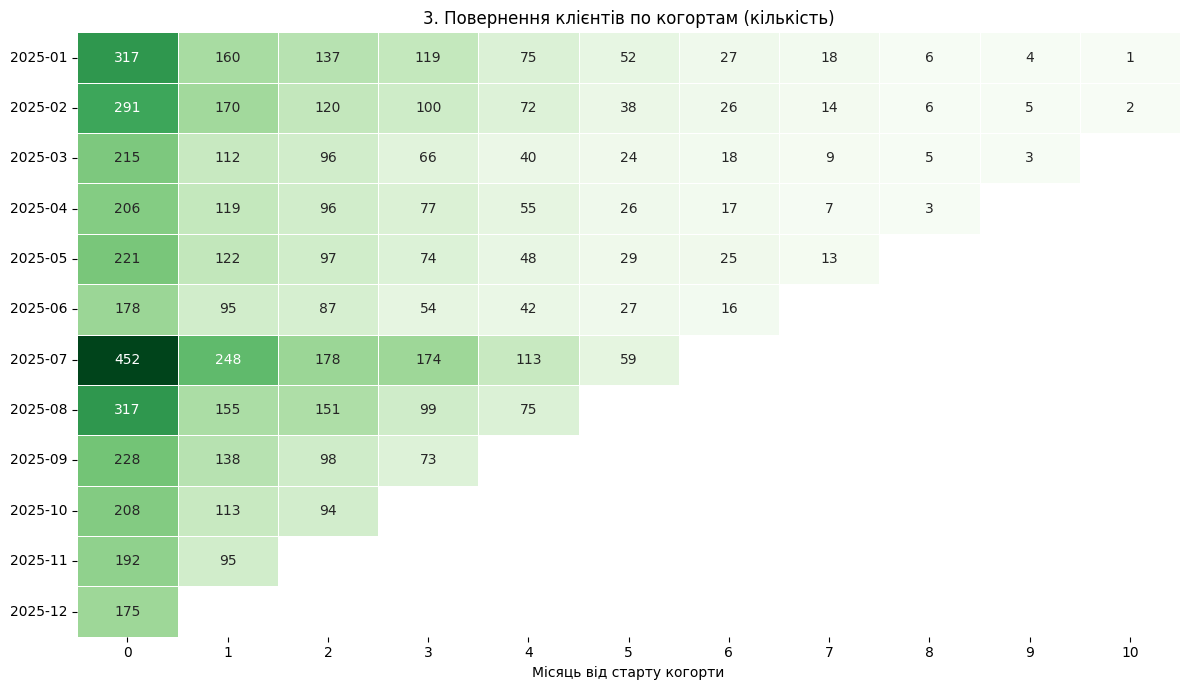

In [16]:
# Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(retention_pivot, annot=True, fmt="g", cmap="Greens", linewidths=0.5,
    cbar=False)
plt.title("3. Повернення клієнтів по когортам (кількість)")
plt.xlabel("Місяць від старту когорти")
plt.ylabel("")
plt.tight_layout()
add_current_fig("3) Retention (Count)", "Скільки унікальних користувачів повернулось у кожному місяці життя когорти.")
plt.show()

In [17]:
#Розмір когорти (кількість клієнтів у місяці 0)
cohort_size=(df_orders[df_orders["month_elapsed"]==0].groupby("cohort_month")["user_id"].nunique())
cohort_size

,user_id
cohort_month,
2025-01,317
2025-02,291
2025-03,215
2025-04,206
2025-05,221
2025-06,178
2025-07,452
2025-08,317
2025-09,228


In [18]:
# Retention rate у відсотках
retention_pct = retention_pivot.div(cohort_size, axis=0) * 100
retention_pct

month_elapsed,0,1,2,3,4,5,6,7,8,9,10
cohort_month,,,,,,,,,,,
2025-01,100.0,50.473186,43.217666,37.539432,23.659306,16.403785,8.517350,5.678233,1.892744,1.261830,0.315457
2025-02,100.0,58.419244,41.237113,34.364261,24.742268,13.058419,8.934708,4.810997,2.061856,1.718213,0.687285
2025-03,100.0,52.093023,44.651163,30.697674,18.604651,11.162791,8.372093,4.186047,2.325581,1.395349,NaN
2025-04,100.0,57.766990,46.601942,37.378641,26.699029,12.621359,8.252427,3.398058,1.456311,NaN,NaN
2025-05,100.0,55.203620,43.891403,33.484163,21.719457,13.122172,11.312217,5.882353,NaN,NaN,NaN
2025-06,100.0,53.370787,48.876404,30.337079,23.595506,15.168539,8.988764,NaN,NaN,NaN,NaN
2025-07,100.0,54.867257,39.380531,38.495575,25.000000,13.053097,NaN,NaN,NaN,NaN,NaN
2025-08,100.0,48.895899,47.634069,31.230284,23.659306,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,100.0,60.526316,42.982456,32.017544,NaN,NaN,NaN,NaN,NaN,NaN,NaN


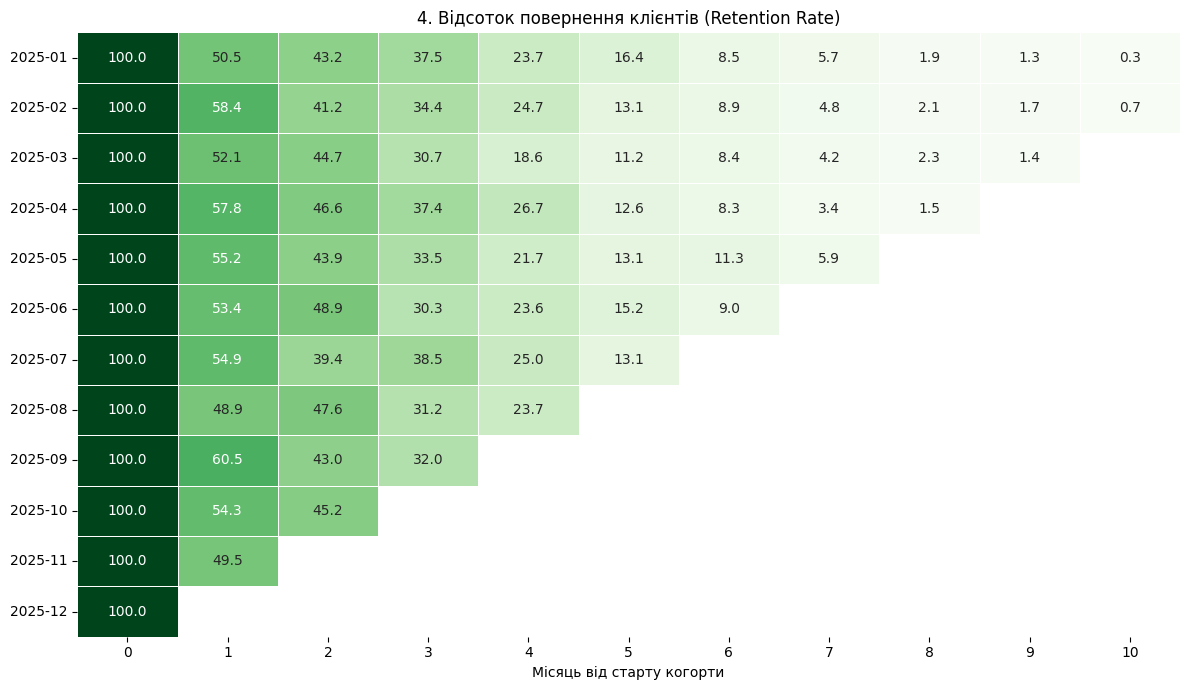

In [19]:
# Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(retention_pct, annot=True, fmt=".1f", cmap="Greens", linewidths=0.5,
    cbar=False)
plt.title("4. Відсоток повернення клієнтів (Retention Rate)")
plt.xlabel("Місяць від старту когорти")
plt.ylabel("")
plt.tight_layout()
add_current_fig("4) Retention Rate (%)", "Відсоток повернення: retention_count / cohort_size * 100.")
plt.show()

#Revenue i Cumulative Revenue

In [20]:
# Revenue за когортами і періодами
rev_by_cohort = (
   df_orders
   .groupby(["cohort_month", "month_elapsed"])["purchase_amount"]
   .sum()
   .reset_index(name="revenue")
   .sort_values(["cohort_month", "month_elapsed"])
)
rev_by_cohort

,cohort_month,month_elapsed,revenue
0,2025-01,0,71546.12
1,2025-01,1,31832.39
2,2025-01,2,27705.47
3,2025-01,3,24954.17
4,2025-01,4,15223.97
...,...,...,...
72,2025-10,1,22806.10
73,2025-10,2,17540.53
74,2025-11,0,40640.58
75,2025-11,1,19883.19


In [21]:
# Pivot для Heatmap revenue
rev_matrix = rev_by_cohort.pivot_table(index="cohort_month", columns="month_elapsed", values="revenue")
rev_matrix

month_elapsed,0,1,2,3,4,5,6,7,8,9,10
cohort_month,,,,,,,,,,,
2025-01,71546.12,31832.39,27705.47,24954.17,15223.97,8868.43,4736.33,3716.92,853.40,923.08,50.94
2025-02,63955.02,37557.24,24691.05,17973.29,14228.49,6796.43,4219.57,2160.17,930.94,710.36,301.95
2025-03,49608.85,24615.18,20518.00,12760.99,8196.12,5627.39,3062.91,2264.72,1111.30,436.65,NaN
2025-04,42646.48,23611.48,17374.69,15723.91,9962.10,3880.05,3682.64,1297.29,239.61,NaN,NaN
2025-05,48884.28,25676.03,20206.76,13381.81,11059.78,5924.88,5347.43,1449.82,NaN,NaN,NaN
2025-06,40882.52,19849.40,15117.09,11988.96,9640.96,4436.14,1883.39,NaN,NaN,NaN,NaN
2025-07,101047.45,55519.53,37181.92,34786.91,19805.92,11440.99,NaN,NaN,NaN,NaN,NaN
2025-08,72058.75,32199.83,30226.69,19100.03,14847.21,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,48059.57,30356.51,20955.33,14872.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN


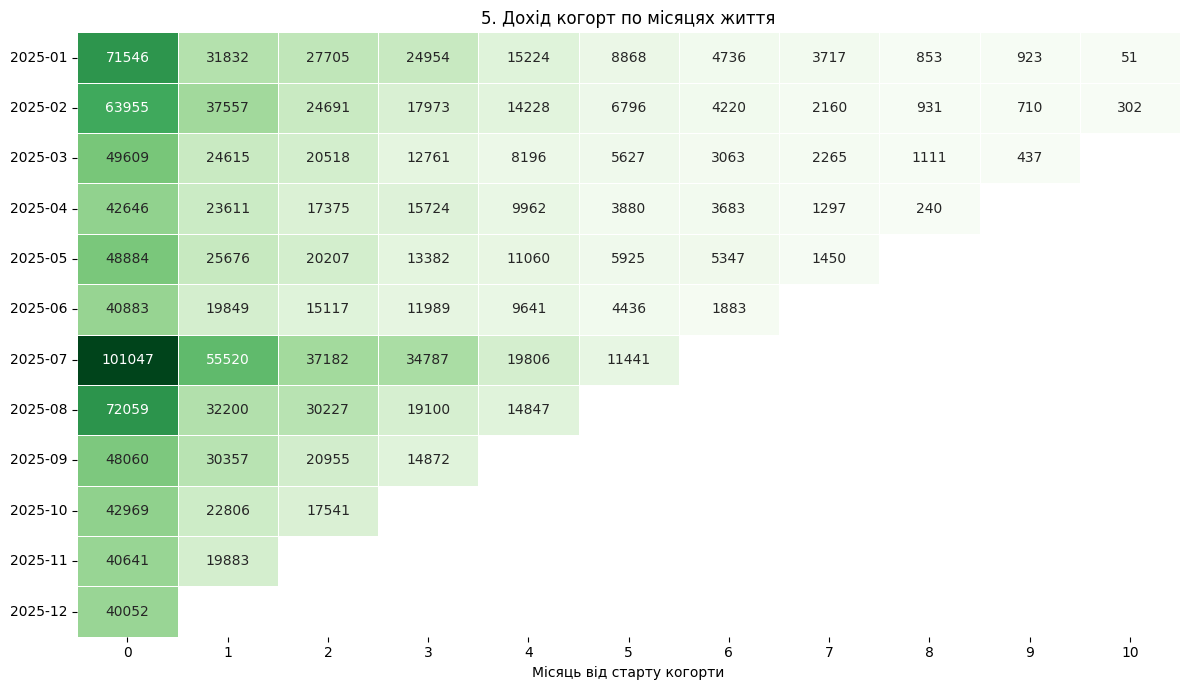

In [22]:
# Heatmap
# Дохід когорт по місяцях життя
plt.figure(figsize=(12, 7))
sns.heatmap(rev_matrix, annot=True, fmt=".0f", cmap="Greens", linewidths=0.5,
    cbar=False)
plt.title("5. Дохід когорт по місяцях життя")
plt.xlabel("Місяць від старту когорти")
plt.ylabel("")
plt.tight_layout()
add_current_fig("5) Revenue by Cohort", "Сума доходу (purchase_amount) для кожної когорти в кожному місяці життя.")
plt.show()

In [23]:
# Накопичувальний revenue
rev_by_cohort["revenue_cum"] = rev_by_cohort.groupby("cohort_month")["revenue"].cumsum()
rev_by_cohort

,cohort_month,month_elapsed,revenue,revenue_cum
0,2025-01,0,71546.12,71546.12
1,2025-01,1,31832.39,103378.51
2,2025-01,2,27705.47,131083.98
3,2025-01,3,24954.17,156038.15
4,2025-01,4,15223.97,171262.12
...,...,...,...,...
72,2025-10,1,22806.10,65775.46
73,2025-10,2,17540.53,83315.99
74,2025-11,0,40640.58,40640.58
75,2025-11,1,19883.19,60523.77


In [24]:
rev_cum_matrix = rev_by_cohort.pivot_table(index="cohort_month", columns="month_elapsed", values="revenue_cum")
rev_cum_matrix

month_elapsed,0,1,2,3,4,5,6,7,8,9,10
cohort_month,,,,,,,,,,,
2025-01,71546.12,103378.51,131083.98,156038.15,171262.12,180130.55,184866.88,188583.80,189437.20,190360.28,190411.22
2025-02,63955.02,101512.26,126203.31,144176.60,158405.09,165201.52,169421.09,171581.26,172512.20,173222.56,173524.51
2025-03,49608.85,74224.03,94742.03,107503.02,115699.14,121326.53,124389.44,126654.16,127765.46,128202.11,NaN
2025-04,42646.48,66257.96,83632.65,99356.56,109318.66,113198.71,116881.35,118178.64,118418.25,NaN,NaN
2025-05,48884.28,74560.31,94767.07,108148.88,119208.66,125133.54,130480.97,131930.79,NaN,NaN,NaN
2025-06,40882.52,60731.92,75849.01,87837.97,97478.93,101915.07,103798.46,NaN,NaN,NaN,NaN
2025-07,101047.45,156566.98,193748.90,228535.81,248341.73,259782.72,NaN,NaN,NaN,NaN,NaN
2025-08,72058.75,104258.58,134485.27,153585.30,168432.51,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,48059.57,78416.08,99371.41,114243.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN


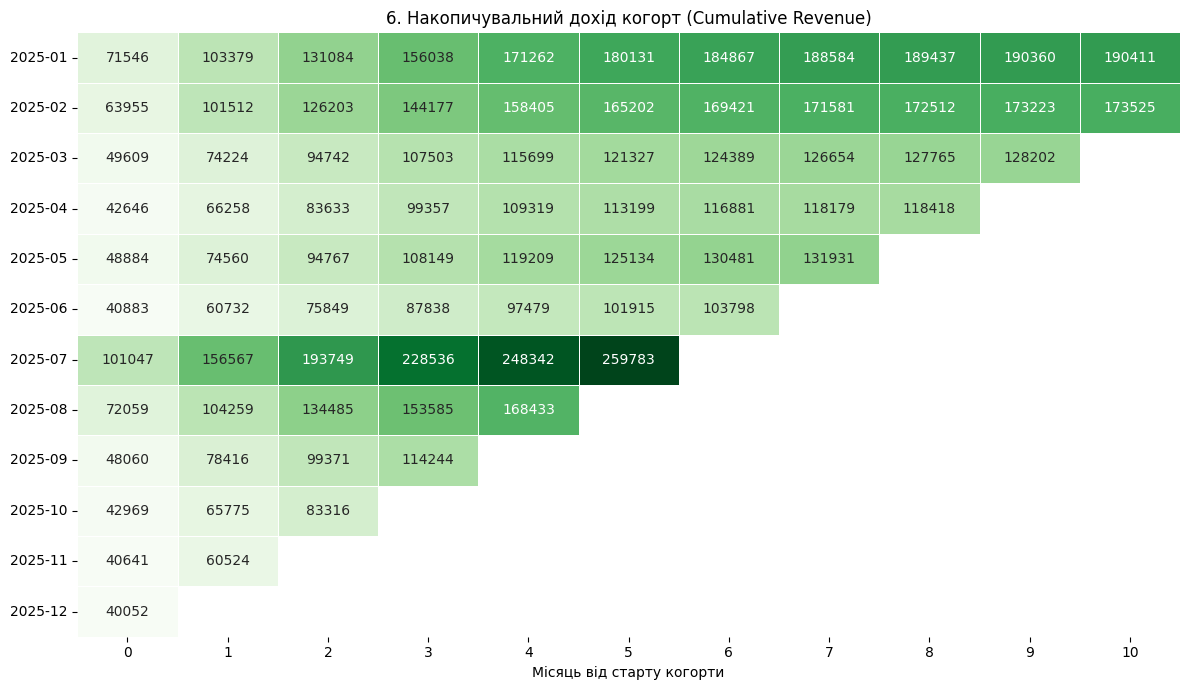

In [25]:
# Heatmap
# Накопичувальний дохід когорт (Cumulative Revenue)
plt.figure(figsize=(12, 7))
sns.heatmap(rev_cum_matrix, annot=True, fmt=".0f", cmap="Greens",linewidths=0.5,
    cbar=False )  # вимикає шкалу справа )
plt.title("6. Накопичувальний дохід когорт (Cumulative Revenue)")
plt.xlabel("Місяць від старту когорти")
plt.ylabel("")
plt.tight_layout()
add_current_fig("6) Cumulative Revenue", "Накопичувальний дохід (cumsum) по місяцях життя когорти.")
plt.show()

#Розподіл клієнтів за каналами залучення по когортам

In [26]:
# Групуємо дані: кількість клієнтів по місяцях і каналах
order_channel_count=(
  df_orders
  .groupby(["cohort_month", "order_channel"])["user_id"]
  .nunique()
  .reset_index(name="users")
  )
order_channel_count

,cohort_month,order_channel,users
0,2025-01,Email,175
1,2025-01,Facebook,194
2,2025-01,Google Ads,183
3,2025-01,Instagram,194
4,2025-01,Referral,156
...,...,...,...
67,2025-12,Facebook,50
68,2025-12,Google Ads,44
69,2025-12,Instagram,63
70,2025-12,Referral,46


In [27]:
#Pivot-таблиця
order_channel_pivot=order_channel_count.pivot_table(index="cohort_month", columns="order_channel", values="users")
order_channel_pivot

order_channel,Email,Facebook,Google Ads,Instagram,Referral,Unknown
cohort_month,,,,,,
2025-01,175.0,194.0,183.0,194.0,156.0,115.0
2025-02,141.0,166.0,172.0,189.0,139.0,115.0
2025-03,110.0,119.0,127.0,135.0,100.0,82.0
2025-04,99.0,114.0,122.0,137.0,101.0,64.0
2025-05,93.0,139.0,124.0,141.0,120.0,74.0
2025-06,84.0,104.0,95.0,120.0,83.0,76.0
2025-07,215.0,269.0,259.0,267.0,223.0,159.0
2025-08,158.0,178.0,171.0,196.0,144.0,109.0
2025-09,97.0,108.0,129.0,137.0,106.0,56.0


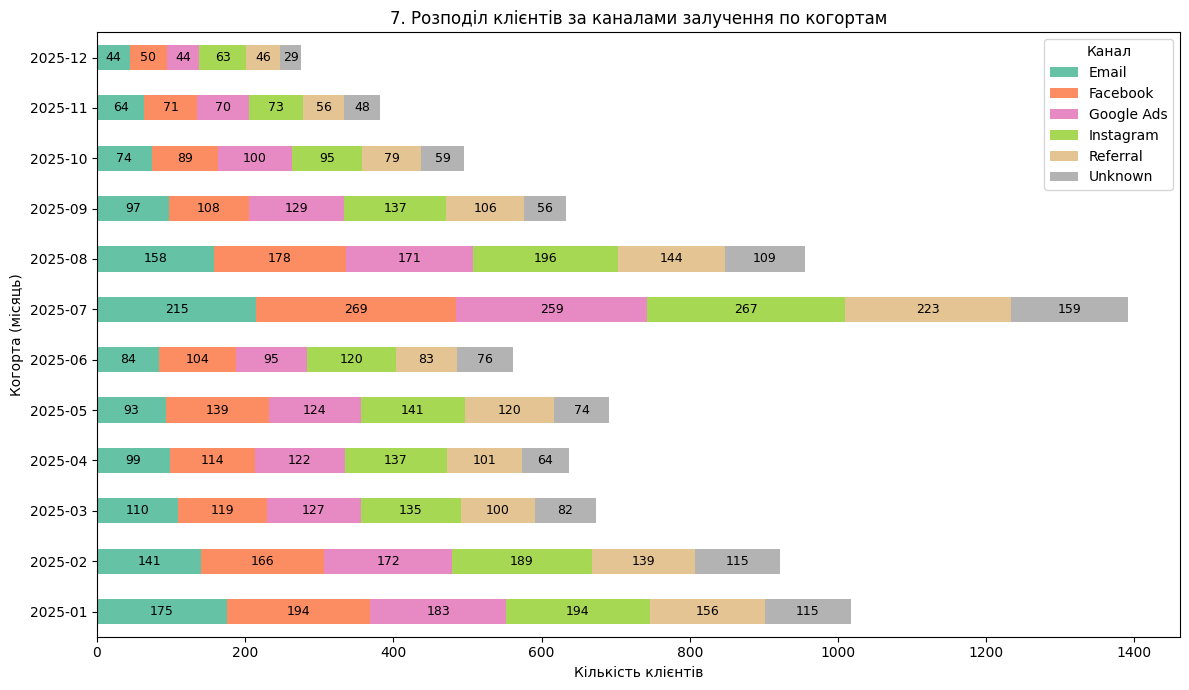

In [28]:
# Побудова stacked bar (горизонтальна діаграма)
ax = order_channel_pivot.plot(kind="barh", stacked=True, figsize=(12,7), colormap="Set2")

plt.title("7. Розподіл клієнтів за каналами залучення по когортам")
plt.xlabel("Кількість клієнтів")
plt.ylabel("Когорта (місяць)")
plt.legend(title="Канал")

# Підписи всередині сегментів
for bars in ax.containers:
    ax.bar_label(bars, label_type="center", fontsize=9)

plt.tight_layout()
add_current_fig("7) Order Channel", "Розподіл клієнтів за каналами залучення по когортам.")
plt.close(fig)


#Розподіл клієнтів за методами оплати по когортам

In [29]:
# Групуємо дані: кількість клієнтів по місяцях і методам оплати
payment_method_count=(
  df_orders
  .groupby(["cohort_month", "payment_method"])["user_id"]
  .nunique()
  .reset_index(name="users")
  )
payment_method_count

,cohort_month,payment_method,users
0,2025-01,Apple Pay,116
1,2025-01,Cash on Delivery,43
2,2025-01,Credit Card,244
3,2025-01,Debit Card,219
4,2025-01,Google Pay,87
...,...,...,...
67,2025-12,Cash on Delivery,11
68,2025-12,Credit Card,90
69,2025-12,Debit Card,68
70,2025-12,Google Pay,18


In [30]:
#Pivot-таблиця
payment_method_pivot=payment_method_count.pivot_table(index="cohort_month", columns="payment_method", values="users")
payment_method_pivot

payment_method,Apple Pay,Cash on Delivery,Credit Card,Debit Card,Google Pay,PayPal
cohort_month,,,,,,
2025-01,116.0,43.0,244.0,219.0,87.0,197.0
2025-02,116.0,38.0,240.0,195.0,81.0,180.0
2025-03,73.0,28.0,171.0,148.0,61.0,129.0
2025-04,63.0,28.0,171.0,148.0,60.0,121.0
2025-05,71.0,19.0,176.0,147.0,66.0,132.0
2025-06,62.0,19.0,149.0,117.0,51.0,114.0
2025-07,164.0,54.0,345.0,315.0,134.0,269.0
2025-08,111.0,49.0,248.0,208.0,78.0,183.0
2025-09,73.0,23.0,170.0,133.0,54.0,123.0


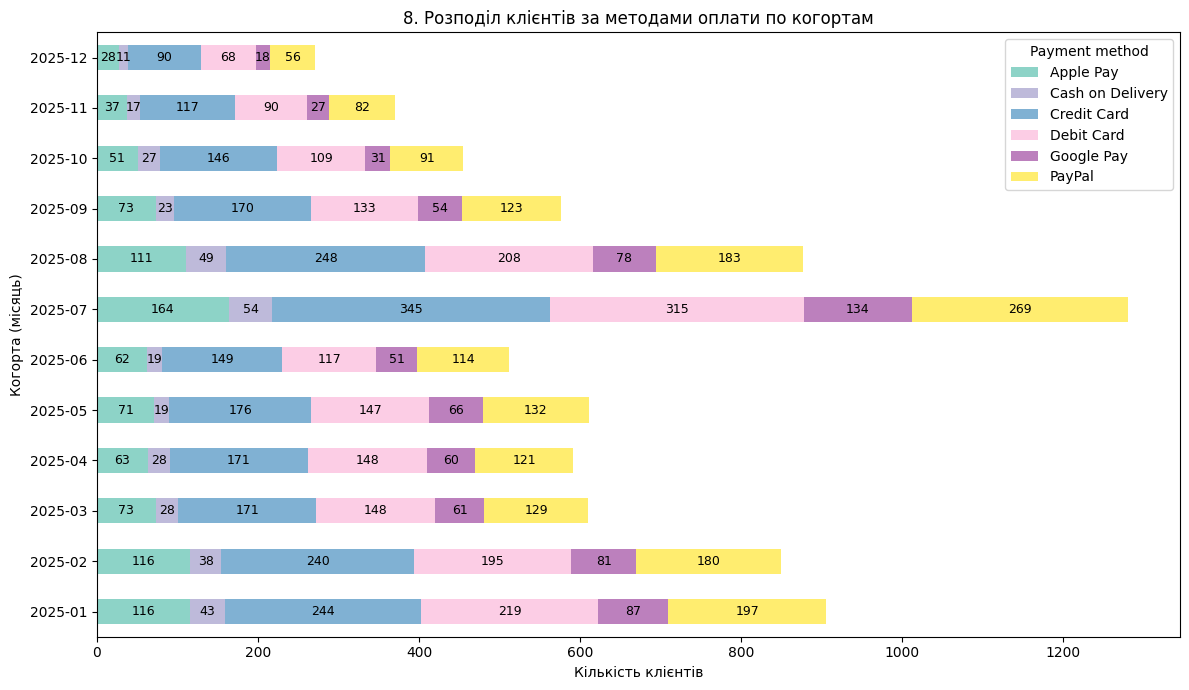

In [31]:
# Побудова stacked bar (горизонтальна діаграма)
ax = payment_method_pivot.plot(kind="barh", stacked=True, figsize=(12,7), colormap="Set3")

plt.title("8. Розподіл клієнтів за методами оплати по когортам")
plt.xlabel("Кількість клієнтів")
plt.ylabel("Когорта (місяць)")
plt.legend(title="Payment method")

# Підписи всередині сегментів
for bars in ax.containers:
    ax.bar_label(bars, label_type="center", fontsize=9)

plt.tight_layout()
add_current_fig("8) Payment Method", "Розподіл клієнтів за методами оплати по когортам.")
plt.close(fig)

In [33]:
report_file = save_report_html("cohort_report.html")
files.download(report_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>